In [6]:
import kagglehub

path = kagglehub.dataset_download(
    "vivek468/superstore-dataset-final"
)

print("Dataset path:", path)

C:\Users\User01\AppData\Roaming\Python\Python314\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset path: C:\Users\User01\.cache\kagglehub\datasets\vivek468\superstore-dataset-final\versions\1


In [7]:
import os


print(os.listdir(path))

['Sample - Superstore.csv']


In [8]:
!pip install matplotlib seaborn numpy

!pip install xgboost lightgbm prophet


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
!pip install -U scikit-learn

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
!pip install psycopg2-binary

import sys

!{sys.executable} -m pip install sqlalchemy psycopg2-binary

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [11]:
import pandas as pd
from sqlalchemy import create_engine
DATABASE_URL = os.environ["DATABASE_URL"]

engine = create_engine(DATABASE_URL)
df = pd.read_sql("SELECT * FROM superstore", engine)

print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

Shape: (9994, 26)

Columns:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit', 'Year', 'Month', 'Month Name', 'Quarter', 'Profit Margin']

First 5 rows:


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Product Name,Sales,Quantity,Discount,Profit,Year,Month,Month Name,Quarter,Profit Margin
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,11,November,4,16.00
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,11,November,4,30.00
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,6,June,2,47.00
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,10,October,4,-40.00
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,10,October,4,11.25


In [12]:
# Basic information about the dataset

print("Dataset Shape:", df.shape)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Dataset Shape: (9994, 26)

Data Types:
Row ID             int64
Order ID             str
Order Date           str
Ship Date            str
Ship Mode            str
Customer ID          str
Customer Name        str
Segment              str
Country              str
City                 str
State                str
Postal Code        int64
Region               str
Product ID           str
Category             str
Sub-Category         str
Product Name         str
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
Year               int64
Month              int64
Month Name           str
Quarter            int64
Profit Margin    float64
dtype: object

Missing Values:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category      

In [13]:
# Basic statistical summary

display(df.describe())

,Row ID,Postal Code,Sales,Quantity,Discount,Profit,Year,Month,Quarter,Profit Margin
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896,2015.722233,7.809686,2.882329,12.031393
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108,1.123555,3.284654,1.058086,46.675435
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000,2014.000000,1.000000,1.000000,-275.000000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750,2015.000000,5.000000,2.000000,7.500000
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500,2016.000000,9.000000,3.000000,27.000000
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000,2017.000000,11.000000,4.000000,36.250000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000,2017.000000,12.000000,4.000000,50.000000


In [14]:
# Unique values in important categorical columns

for col in ["Ship Mode", "Segment", "Region", "Category", "Sub-Category"]:
    print(f"\n--- {col} ---")
    print(df[col].unique())


--- Ship Mode ---
<StringArray>
['Second Class', 'Standard Class', 'First Class', 'Same Day']
Length: 4, dtype: str

--- Segment ---
<StringArray>
['Consumer', 'Corporate', 'Home Office']
Length: 3, dtype: str

--- Region ---
<StringArray>
['South', 'West', 'Central', 'East']
Length: 4, dtype: str

--- Category ---
<StringArray>
['Furniture', 'Office Supplies', 'Technology']
Length: 3, dtype: str

--- Sub-Category ---
<StringArray>
[  'Bookcases',      'Chairs',      'Labels',      'Tables',     'Storage',
 'Furnishings',         'Art',      'Phones',     'Binders',  'Appliances',
       'Paper', 'Accessories',   'Envelopes',   'Fasteners',    'Supplies',
    'Machines',     'Copiers']
Length: 17, dtype: str


In [15]:
# Make a copy so our original dataset remains unchanged
df_clean = df.copy()

# Convert date columns from object → datetime
df_clean["Order Date"] = pd.to_datetime(df_clean["Order Date"])
df_clean["Ship Date"] = pd.to_datetime(df_clean["Ship Date"])

# Create useful time-based features
df_clean["Year"] = df_clean["Order Date"].dt.year
df_clean["Month"] = df_clean["Order Date"].dt.month
df_clean["Month Name"] = df_clean["Order Date"].dt.month_name()
df_clean["Quarter"] = df_clean["Order Date"].dt.quarter

# Create profit margin
df_clean["Profit Margin"] = (
    df_clean["Profit"] / df_clean["Sales"]
) * 100

print(df_clean.dtypes)

Row ID                    int64
Order ID                    str
Order Date       datetime64[us]
Ship Date        datetime64[us]
Ship Mode                   str
Customer ID                 str
Customer Name               str
Segment                     str
Country                     str
City                        str
State                       str
Postal Code               int64
Region                      str
Product ID                  str
Category                    str
Sub-Category                str
Product Name                str
Sales                   float64
Quantity                  int64
Discount                float64
Profit                  float64
Year                      int32
Month                     int32
Month Name                  str
Quarter                   int32
Profit Margin           float64
dtype: object


In [16]:
display(df_clean.head())

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Product Name,Sales,Quantity,Discount,Profit,Year,Month,Month Name,Quarter,Profit Margin
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,11,November,4,16.00
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,11,November,4,30.00
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,6,June,2,47.00
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,10,October,4,-40.00
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,10,October,4,11.25


In [17]:
print("New shape:", df_clean.shape)
print("\nNew columns:")
print(df_clean.columns.tolist())

New shape: (9994, 26)

New columns:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit', 'Year', 'Month', 'Month Name', 'Quarter', 'Profit Margin']


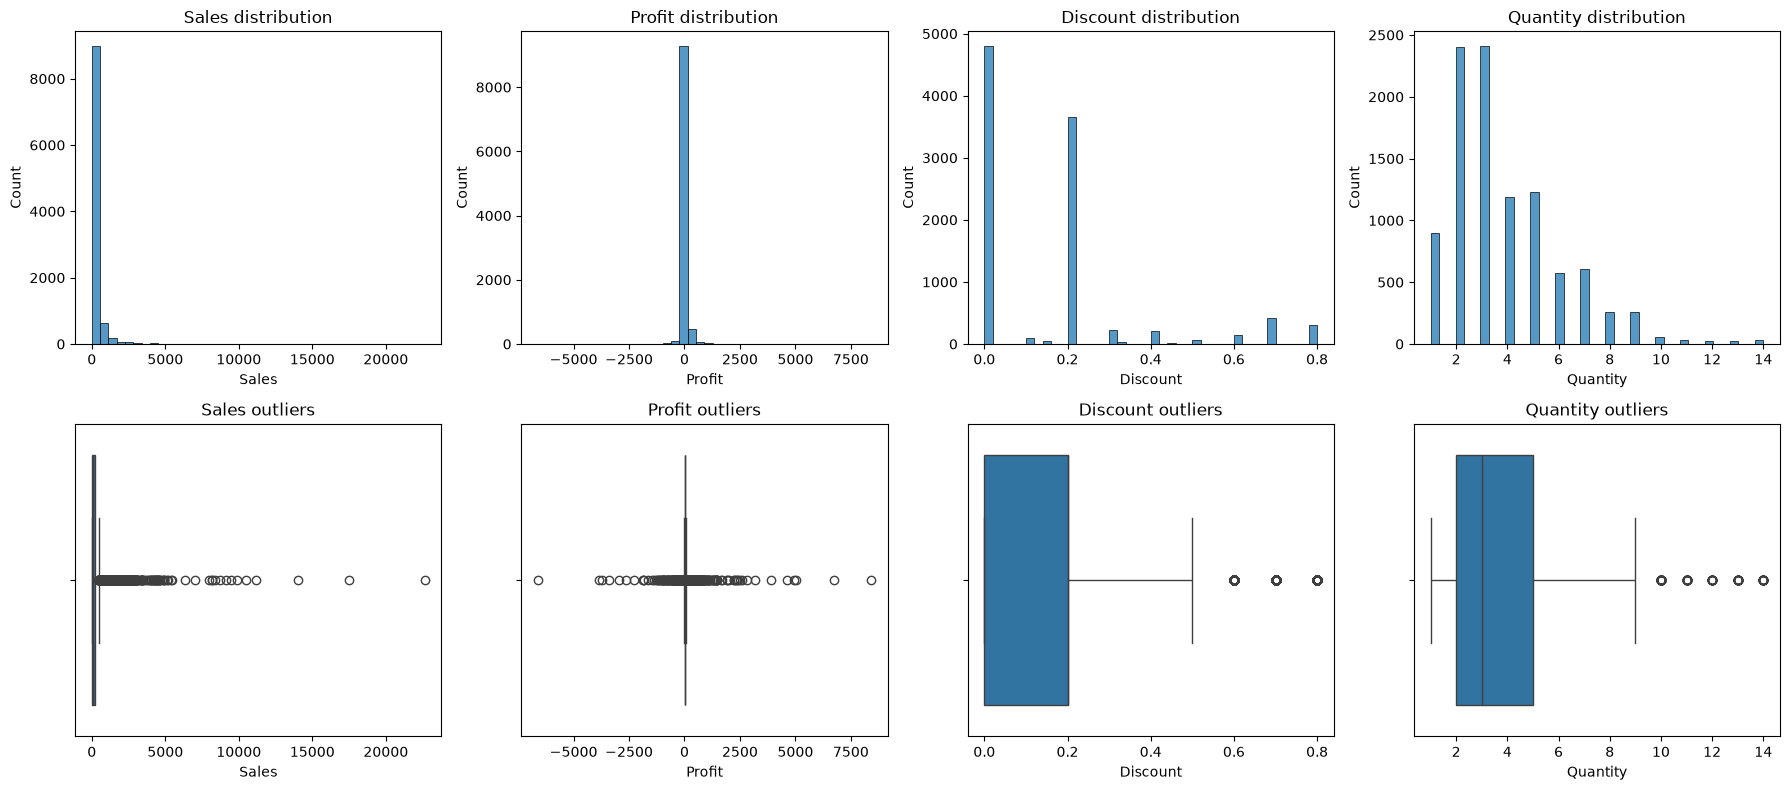

Outlier counts (IQR method):

Sales: 1167 outliers (outside [-271.71, 498.93])
Profit: 1881 outliers (outside [-39.72, 70.82])
Discount: 856 outliers (outside [-0.30, 0.50])
Quantity: 170 outliers (outside [-2.50, 9.50])


In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = ["Sales", "Profit", "Discount", "Quantity"]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))

for i, col in enumerate(numeric_cols):
    sns.histplot(df_clean[col], bins=40, ax=axes[0, i])
    axes[0, i].set_title(f"{col} distribution")

    sns.boxplot(x=df_clean[col], ax=axes[1, i])
    axes[1, i].set_title(f"{col} outliers")

plt.tight_layout()
plt.show()

# Quantify outliers using the IQR method
print("Outlier counts (IQR method):\n")

for col in numeric_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df_clean[(df_clean[col] < lower) | (df_clean[col] > upper)]
    print(f"{col}: {len(outliers)} outliers (outside [{lower:.2f}, {upper:.2f}])")

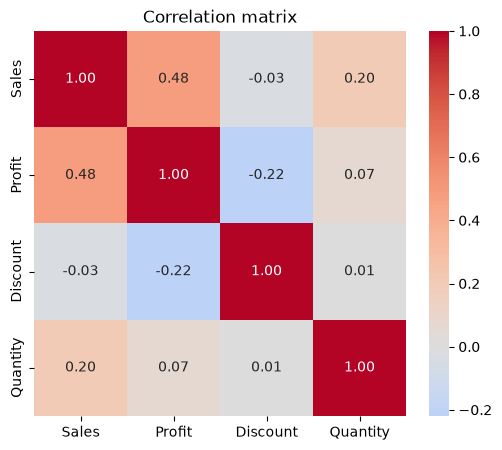

Discount   -0.219487
Quantity    0.066253
Sales       0.479064
Profit      1.000000
Name: Profit, dtype: float64


In [19]:
# Discount vs Profit correlation
correlation_matrix = df_clean[["Sales", "Profit", "Discount", "Quantity"]].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Correlation matrix")
plt.show()

print(correlation_matrix["Profit"].sort_values())

count    9994.000000
mean        3.958175
std         1.747567
min         0.000000
25%         3.000000
50%         4.000000
75%         5.000000
max         7.000000
Name: Shipping Delay, dtype: float64


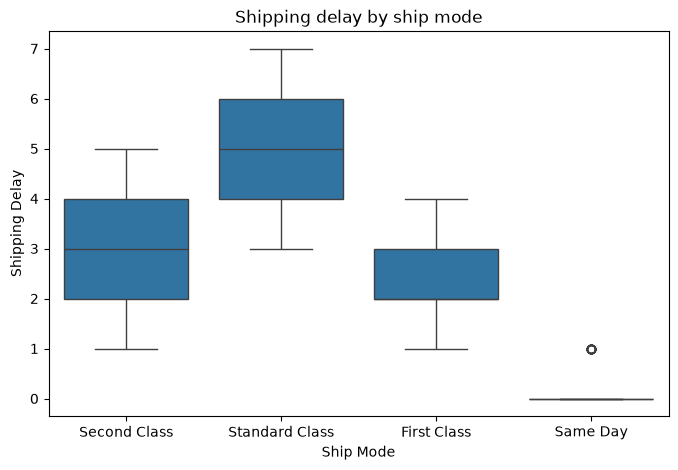

In [20]:
# Shipping delay
df_clean["Shipping Delay"] = (df_clean["Ship Date"] - df_clean["Order Date"]).dt.days

print(df_clean["Shipping Delay"].describe())

plt.figure(figsize=(8, 5))
sns.boxplot(data=df_clean, x="Ship Mode", y="Shipping Delay")
plt.title("Shipping delay by ship mode")
plt.show()

In [21]:
# Discount buckets
def bucket_discount(d):
    if d == 0: return "none"
    elif d <= 0.2: return "low"
    elif d <= 0.4: return "medium"
    else: return "high"

df_clean["Discount Bucket"] = df_clean["Discount"].apply(bucket_discount)
df_clean["Discount Bucket"].value_counts()

Discount Bucket
none      4798
low       3803
high       933
medium     460
Name: count, dtype: int64

In [22]:
# Day of week
df_clean["Order Day of Week"] = df_clean["Order Date"].dt.day_name()

In [23]:
from sklearn.preprocessing import LabelEncoder
import pickle

encoders = {}
for col in ["Category", "Sub-Category", "Region", "Segment"]:
    le = LabelEncoder()
    df_clean[f"{col.replace('-', '_')}_enc"] = le.fit_transform(df_clean[col])
    encoders[col] = le

with open("encoders.pkl", "wb") as f:
    pickle.dump(encoders, f)

In [24]:
# Monthly aggregation + lag features for forecasting
monthly_features = (
    df_clean.groupby(pd.Grouper(key="Order Date", freq="MS"))
    .agg(total_sales=("Sales", "sum"), total_profit=("Profit", "sum"))
    .reset_index()
    .sort_values("Order Date")
)

for lag in [1, 2, 3]:
    monthly_features[f"sales_lag_{lag}"] = monthly_features["total_sales"].shift(lag)
    monthly_features[f"profit_lag_{lag}"] = monthly_features["total_profit"].shift(lag)

monthly_features["sales_rolling_3"] = monthly_features["total_sales"].shift(1).rolling(3).mean()     
monthly_features["profit_rolling_3"] = monthly_features["total_profit"].shift(1).rolling(3).mean()   # new
monthly_features = monthly_features.dropna().reset_index(drop=True)

monthly_features.head()

,Order Date,total_sales,total_profit,sales_lag_1,profit_lag_1,sales_lag_2,profit_lag_2,sales_lag_3,profit_lag_3,sales_rolling_3,profit_rolling_3
0,2014-04-01,28295.3450,3488.8352,55691.0090,498.7299,4519.8920,862.3084,14236.895,2450.1907,24815.932000,1270.409667
1,2014-05-01,23648.2870,2738.7096,28295.3450,3488.8352,55691.0090,498.7299,4519.892,862.3084,29502.082000,1616.624500
2,2014-06-01,34595.1276,4976.5244,23648.2870,2738.7096,28295.3450,3488.8352,55691.009,498.7299,35878.213667,2242.091567
3,2014-07-01,33946.3930,-841.4826,34595.1276,4976.5244,23648.2870,2738.7096,28295.345,3488.8352,28846.253200,3734.689733
4,2014-08-01,27909.4685,5318.1050,33946.3930,-841.4826,34595.1276,4976.5244,23648.287,2738.7096,30729.935867,2291.250467


In [25]:
# Time-respecting split
split_idx = int(len(monthly_features) * 0.8)
train = monthly_features.iloc[:split_idx]
test = monthly_features.iloc[split_idx:]

print(f"Train: {train['Order Date'].min().date()} to {train['Order Date'].max().date()} ({len(train)} months)")
print(f"Test:  {test['Order Date'].min().date()} to {test['Order Date'].max().date()} ({len(test)} months)")

Train: 2014-04-01 to 2017-03-01 (36 months)
Test:  2017-04-01 to 2017-12-01 (9 months)


In [26]:
import numpy as np

def evaluate(y_true, y_pred, label):
    mae = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - y_true.mean()) ** 2)
    r2 = 1 - (ss_res / ss_tot)
    print(f"{label:25s} MAE={mae:,.0f}  RMSE={rmse:,.0f}  MAPE={mape:.1f}%  R2={r2:.3f}")
    return {"label": label, "mae": mae, "rmse": rmse, "mape": mape, "r2": r2}

results = []

In [27]:
# 4. Sales baselines
naive_pred = np.full(len(test), train["total_sales"].iloc[-1])
results.append(evaluate(test["total_sales"].values, naive_pred, "Naive (last value)"))

seasonal_pred = []
for date in test["Order Date"]:
    lookup_date = date - pd.DateOffset(years=1)
    match = monthly_features[monthly_features["Order Date"] == lookup_date]
    seasonal_pred.append(match["total_sales"].values[0] if len(match) else train["total_sales"].mean())
results.append(evaluate(test["total_sales"].values, np.array(seasonal_pred), "Seasonal naive (last year)"))

Naive (last value)        MAE=21,460  RMSE=26,502  MAPE=31.1%  R2=-0.128
Seasonal naive (last year) MAE=16,706  RMSE=20,057  MAPE=23.5%  R2=0.354


In [28]:
# 5. Linear regression baseline (also creates train_lr/test_lr used everywhere below)
from sklearn.linear_model import LinearRegression

train_lr = train.copy()
train_lr["t"] = range(len(train_lr))
train_lr["month"] = train_lr["Order Date"].dt.month

test_lr = test.copy()
test_lr["t"] = range(len(train_lr), len(train_lr) + len(test_lr))
test_lr["month"] = test_lr["Order Date"].dt.month

X_train = train_lr[["t", "month"]]
y_train = train_lr["total_sales"]
X_test = test_lr[["t", "month"]]
y_test = test_lr["total_sales"]

lr = LinearRegression()
lr.fit(X_train, y_train)
results.append(evaluate(y_test.values, lr.predict(X_test), "Linear regression (trend+month)"))

pd.DataFrame(results).sort_values("mape")

Linear regression (trend+month) MAE=10,751  RMSE=15,001  MAPE=16.1%  R2=0.639


,label,mae,rmse,mape,r2
2,Linear regression (trend+month),10751.258356,15000.594281,16.102884,0.638758
1,Seasonal naive (last year),16705.740867,20056.770437,23.450039,0.354191
0,Naive (last value),21460.051800,26501.807293,31.054987,-0.127542


In [29]:
# 6. Tree models + Prophet on sales (enriched features)
feature_cols = ["t", "month", "sales_lag_1", "sales_lag_2", "sales_lag_3", "sales_rolling_3"]
X_train = train_lr[feature_cols]
y_train = train_lr["total_sales"]
X_test = test_lr[feature_cols]
y_test = test_lr["total_sales"]

from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(n_estimators=200, max_depth=4, random_state=42)
rf.fit(X_train, y_train)
results.append(evaluate(y_test.values, rf.predict(X_test), "Random Forest"))

from xgboost import XGBRegressor
xgb = XGBRegressor(n_estimators=200, max_depth=3, learning_rate=0.05, random_state=42)
xgb.fit(X_train, y_train)
results.append(evaluate(y_test.values, xgb.predict(X_test), "XGBoost"))

from lightgbm import LGBMRegressor
lgbm = LGBMRegressor(n_estimators=200, max_depth=3, learning_rate=0.05, random_state=42)
lgbm.fit(X_train, y_train)
results.append(evaluate(y_test.values, lgbm.predict(X_test), "LightGBM"))

from prophet import Prophet
prophet_train = train.rename(columns={"Order Date": "ds", "total_sales": "y"})[["ds", "y"]]
m = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
m.fit(prophet_train)
future = test[["Order Date"]].rename(columns={"Order Date": "ds"})
forecast = m.predict(future)
results.append(evaluate(test["total_sales"].values, forecast["yhat"].values, "Prophet"))

results_df = pd.DataFrame(results).sort_values("mape")
results_df

Random Forest             MAE=13,423  RMSE=17,397  MAPE=18.3%  R2=0.514
XGBoost                   MAE=16,272  RMSE=18,563  MAPE=23.0%  R2=0.447
[LightGBM] [Warning] There are no meaningful features which satisfy the provided configuration. Decreasing Dataset parameters min_data_in_bin or min_data_in_leaf and re-constructing Dataset might resolve this warning.
[LightGBM] [Info] Total Bins 0
[LightGBM] [Info] Number of data points in the train set: 36, number of used features: 0
[LightGBM] [Info] Start training from score 44796.741130
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because

Importing plotly failed. Interactive plots will not work.
17:16:44 - cmdstanpy - INFO - Chain [1] start processing
17:16:45 - cmdstanpy - INFO - Chain [1] done processing


Prophet                   MAE=12,076  RMSE=13,974  MAPE=18.7%  R2=0.687


,label,mae,rmse,mape,r2
2,Linear regression (trend+month),10751.258356,15000.594281,16.102884,0.638758
3,Random Forest,13423.084020,17397.097228,18.262494,0.514113
6,Prophet,12075.867032,13974.101979,18.741844,0.686506
4,XGBoost,16271.767020,18563.141083,23.000124,0.446797
1,Seasonal naive (last year),16705.740867,20056.770437,23.450039,0.354191
5,LightGBM,24946.821861,33932.100299,29.949311,-0.848431
0,Naive (last value),21460.051800,26501.807293,31.054987,-0.127542


In [30]:
# 7. Profit models — consolidated, single results table
profit_feature_cols = ["t", "month", "profit_lag_1", "profit_lag_2", "profit_lag_3", "profit_rolling_3"]
X_train_p = train_lr[profit_feature_cols]
X_test_p = test_lr[profit_feature_cols]
y_train_p = train_lr["total_profit"]
y_test_p = test_lr["total_profit"]

profit_results = []

lr_p = LinearRegression()
lr_p.fit(X_train_p, y_train_p)
profit_results.append(evaluate(y_test_p.values, lr_p.predict(X_test_p), "Linear regression (profit, own lags)"))

naive_pred_p = np.full(len(test), train["total_profit"].iloc[-1])
profit_results.append(evaluate(y_test_p.values, naive_pred_p, "Naive (profit)"))

prophet_train_p = train.rename(columns={"Order Date": "ds", "total_profit": "y"})[["ds", "y"]]
m_p = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
m_p.fit(prophet_train_p)
future_p = test[["Order Date"]].rename(columns={"Order Date": "ds"})
forecast_p = m_p.predict(future_p)
profit_results.append(evaluate(test["total_profit"].values, forecast_p["yhat"].values, "Prophet (profit)"))

profit_results_df = pd.DataFrame(profit_results).sort_values("rmse")
profit_results_df

Linear regression (profit, own lags) MAE=2,451  RMSE=3,206  MAPE=82.7%  R2=-0.358
Naive (profit)            MAE=6,982  RMSE=7,504  MAPE=231.9%  R2=-6.441


17:16:46 - cmdstanpy - INFO - Chain [1] start processing
17:16:47 - cmdstanpy - INFO - Chain [1] done processing


Prophet (profit)          MAE=2,956  RMSE=3,845  MAPE=96.9%  R2=-0.954


,label,mae,rmse,mape,r2
0,"Linear regression (profit, own lags)",2450.607538,3205.946594,82.685422,-0.358199
2,Prophet (profit),2956.156479,3845.071146,96.875462,-0.953707
1,Naive (profit),6981.550722,7503.965346,231.926556,-6.441018


In [31]:
# 7b. Profit models — tree-based comparison (Random Forest, XGBoost, LightGBM)
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

rf_p = RandomForestRegressor(n_estimators=200, max_depth=4, random_state=42)
rf_p.fit(X_train_p, y_train_p)
profit_results.append(evaluate(y_test_p.values, rf_p.predict(X_test_p), "Random Forest (profit)"))

xgb_p = XGBRegressor(n_estimators=200, max_depth=3, learning_rate=0.05, random_state=42)
xgb_p.fit(X_train_p, y_train_p)
profit_results.append(evaluate(y_test_p.values, xgb_p.predict(X_test_p), "XGBoost (profit)"))

lgbm_p = LGBMRegressor(n_estimators=200, max_depth=3, learning_rate=0.05, random_state=42)
lgbm_p.fit(X_train_p, y_train_p)
profit_results.append(evaluate(y_test_p.values, lgbm_p.predict(X_test_p), "LightGBM (profit)"))

profit_results_df = pd.DataFrame(profit_results).sort_values("rmse")
profit_results_df

Random Forest (profit)    MAE=2,923  RMSE=3,847  MAPE=122.2%  R2=-0.956
XGBoost (profit)          MAE=4,489  RMSE=5,377  MAPE=167.0%  R2=-2.820
[LightGBM] [Warning] There are no meaningful features which satisfy the provided configuration. Decreasing Dataset parameters min_data_in_bin or min_data_in_leaf and re-constructing Dataset might resolve this warning.
[LightGBM] [Info] Total Bins 0
[LightGBM] [Info] Number of data points in the train set: 36, number of used features: 0
[LightGBM] [Info] Start training from score 5907.020147
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because 

,label,mae,rmse,mape,r2
0,"Linear regression (profit, own lags)",2450.607538,3205.946594,82.685422,-0.358199
5,LightGBM (profit),2968.593997,3322.560640,85.516089,-0.458803
2,Prophet (profit),2956.156479,3845.071146,96.875462,-0.953707
3,Random Forest (profit),2923.410697,3847.482996,122.167736,-0.956159
4,XGBoost (profit),4488.604566,5376.543953,167.020882,-2.819945
1,Naive (profit),6981.550722,7503.965346,231.926556,-6.441018


In [32]:
# 8. Save engineered features
df_clean.to_csv("Superstore_features.csv", index=False)
monthly_features.to_csv("Monthly_features.csv", index=False)

In [33]:
# plt.figure(figsize=(10, 4))
# plt.plot(monthly_features["Order Date"], monthly_features["total_profit"], marker="o")
# plt.title("Monthly profit over time")
# plt.axhline(0, color="gray", linestyle="--")
# plt.show()

In [34]:
import pickle

# Save the two winning models
with open("sales_model.pkl", "wb") as f:
    pickle.dump(lr, f)          # Linear regression, trained on feature_cols (Sales)

with open("profit_model.pkl", "wb") as f:
    pickle.dump(lr_p, f)        # Linear regression, trained on profit_feature_cols (Profit)

# Save what the API needs to build features for FUTURE months:
# - the last 3 known monthly totals (to compute next lag/rolling features)
# - next_t: the trend index to continue from (matches training's "t" scale)
# - last_date: the most recent month in the data, forecasts start after this
forecast_state = {
    "last_date": monthly_features["Order Date"].iloc[-1],
    "next_t": len(monthly_features),
    "last_sales": monthly_features["total_sales"].iloc[-3:].tolist(),
    "last_profit": monthly_features["total_profit"].iloc[-3:].tolist(),
}

with open("forecast_state.pkl", "wb") as f:
    pickle.dump(forecast_state, f)

print(forecast_state)

{'last_date': Timestamp('2017-12-01 00:00:00'), 'next_t': 45, 'last_sales': [77776.9232, 118447.825, 83829.3188], 'last_profit': [9275.2755, 9690.1037, 8483.346800000001]}


In [35]:
# -----------------------------------
# Step 7 — Customer Segmentation (K-Means)
# -----------------------------------

# Reference date for Recency: one day after the most recent order in the dataset
reference_date = df_clean["Order Date"].max() + pd.Timedelta(days=1)

customer_features = (
    df_clean.groupby("Customer ID")
    .agg(
        Recency=("Order Date", lambda x: (reference_date - x.max()).days),
        Frequency=("Order ID", "nunique"),
        Monetary=("Sales", "sum"),
        Profit=("Profit", "sum"),
        Quantity=("Quantity", "sum")
    )
    .reset_index()
)

print("Customers:", len(customer_features))
customer_features.describe()

Customers: 793


,Recency,Frequency,Monetary,Profit,Quantity
count,793.000000,793.000000,793.000000,793.000000,793.000000
mean,147.802018,6.316520,2896.848500,361.156396,47.759142
std,186.211051,2.550885,2628.670117,894.261812,24.842915
min,1.000000,1.000000,4.833000,-6626.389500,2.000000
25%,31.000000,5.000000,1146.050000,36.613100,30.000000
50%,76.000000,6.000000,2256.394000,227.833800,44.000000
75%,184.000000,8.000000,3785.276000,560.007800,63.000000
max,1166.000000,17.000000,25043.050000,8981.323900,150.000000


In [36]:
from sklearn.preprocessing import StandardScaler

cluster_cols = ["Recency", "Frequency", "Monetary", "Profit", "Quantity"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(customer_features[cluster_cols])

X_scaled[:5]

array([[ 0.19988856, -0.51642886,  1.01511197, -0.81016078, -0.71530858],
       [-0.68676201,  1.05264427, -0.70059002, -0.09373862, -0.27224696],
       [ 0.60291154, -0.90869715, -0.4211387 ,  0.08355286, -0.47363861],
       [-0.49331098, -0.12416058,  0.83367962,  0.55572131,  0.6541546 ],
       [ 1.44119935, -1.30096543, -0.76539139, -0.25938287, -1.40004016]])

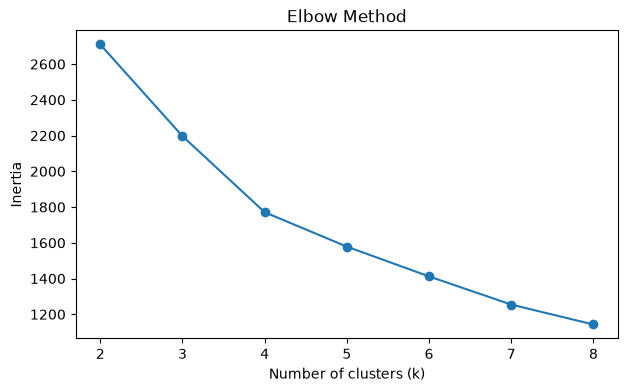

In [37]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertias = []
k_range = range(2, 9)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(list(k_range), inertias, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [38]:
k = 4  # adjust based on the elbow plot if needed

kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
customer_features["Cluster"] = kmeans.fit_predict(X_scaled)

customer_features.groupby("Cluster")[cluster_cols].mean().round(2)

,Recency,Frequency,Monetary,Profit,Quantity
Cluster,,,,,
0,94.21,4.99,1734.26,132.56,33.47
1,538.91,3.68,1444.84,142.53,27.24
2,124.26,8.29,9430.61,2219.11,75.83
3,74.38,8.58,3559.70,346.36,67.85


In [39]:
# Rank clusters by average Monetary value, highest = "High Value"
cluster_rank = (
    customer_features.groupby("Cluster")["Monetary"]
    .mean()
    .sort_values(ascending=False)
    .index
    .tolist()
)

segment_names = ["High Value", "Regular", "Low Value", "At-Risk"]
label_map = dict(zip(cluster_rank, segment_names[:k]))

customer_features["Segment"] = customer_features["Cluster"].map(label_map)

customer_features["Segment"].value_counts()

Segment
Low Value     354
Regular       277
At-Risk       104
High Value     58
Name: count, dtype: int64

In [40]:
import pickle

with open("kmeans_model.pkl", "wb") as f:
    pickle.dump(kmeans, f)

with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

with open("cluster_label_map.pkl", "wb") as f:
    pickle.dump(label_map, f)

customer_features.to_csv("customer_segments.csv", index=False)

customer_features.head()

,Customer ID,Recency,Frequency,Monetary,Profit,Quantity,Cluster,Segment
0,AA-10315,185,5,5563.560,-362.8825,30,0,Low Value
1,AA-10375,20,9,1056.390,277.3824,41,3,Regular
2,AA-10480,260,4,1790.512,435.8274,36,0,Low Value
3,AA-10645,56,6,5086.935,857.8033,64,3,Regular
4,AB-10015,416,3,886.156,129.3465,13,1,At-Risk


In [41]:
# -----------------------------------
# Step 8 — Anomaly Detection (Isolation Forest)
# -----------------------------------

anomaly_features = df_clean[["Sales", "Profit", "Quantity", "Discount"]].copy()

anomaly_features.describe()

,Sales,Profit,Quantity,Discount
count,9994.000000,9994.000000,9994.000000,9994.000000
mean,229.858001,28.656896,3.789574,0.156203
std,623.245101,234.260108,2.225110,0.206452
min,0.444000,-6599.978000,1.000000,0.000000
25%,17.280000,1.728750,2.000000,0.000000
50%,54.490000,8.666500,3.000000,0.200000
75%,209.940000,29.364000,5.000000,0.200000
max,22638.480000,8399.976000,14.000000,0.800000


In [42]:
from sklearn.ensemble import IsolationForest

iso_forest = IsolationForest(
    n_estimators=200,
    contamination=0.02,   # assume ~2% of transactions are anomalies — adjust after reviewing results
    random_state=42
)

df_clean["Anomaly"] = iso_forest.fit_predict(anomaly_features)
df_clean["Anomaly_Score"] = iso_forest.decision_function(anomaly_features)

# fit_predict returns -1 for anomalies, 1 for normal — convert to a readable flag
df_clean["Is_Anomaly"] = df_clean["Anomaly"] == -1

print("Total anomalies flagged:", df_clean["Is_Anomaly"].sum())
print("Percent of transactions:", round(df_clean["Is_Anomaly"].mean() * 100, 2), "%")

Total anomalies flagged: 200
Percent of transactions: 2.0 %


In [43]:
anomalies = (
    df_clean[df_clean["Is_Anomaly"]]
    .sort_values("Anomaly_Score")
    [["Order ID", "Order Date", "Product Name", "Sales", "Profit", "Quantity", "Discount", "Anomaly_Score"]]
)

display(anomalies.head(20))

,Order ID,Order Date,Product Name,Sales,Profit,Quantity,Discount,Anomaly_Score
9042,CA-2016-117121,2016-12-17,GBC Ibimaster 500 Manual ProClick Binding System,9892.740,4946.3700,13,0.0,-0.151550
9641,CA-2015-116638,2015-01-28,Chromcraft Bull-Nose Wood Oval Conference Tabl...,4297.644,-1862.3124,13,0.4,-0.137247
684,US-2017-168116,2017-11-04,Cubify CubeX 3D Printer Triple Head Print,7999.980,-3839.9904,4,0.5,-0.127675
2701,CA-2014-145317,2014-03-18,Cisco TelePresence System EX90 Videoconferenci...,22638.480,-1811.0784,6,0.5,-0.124611
8157,CA-2017-140151,2017-03-23,Canon imageCLASS 2200 Advanced Copier,13999.960,6719.9808,4,0.0,-0.124498
7775,CA-2016-108196,2016-11-25,Cubify CubeX 3D Printer Double Head Print,4499.985,-6599.9780,5,0.7,-0.123437
4195,CA-2017-166709,2017-11-17,Canon imageCLASS 2200 Advanced Copier,10499.970,5039.9856,3,0.0,-0.122454
6827,CA-2016-118689,2016-10-02,Canon imageCLASS 2200 Advanced Copier,17499.950,8399.9760,5,0.0,-0.120103
166,CA-2014-139892,2014-09-08,Lexmark MX611dhe Monochrome Laser Printer,8159.952,-1359.9920,8,0.4,-0.119752
7670,US-2016-140158,2016-10-04,Hewlett Packard LaserJet 3310 Copier,5399.910,2591.9568,9,0.0,-0.118058


In [44]:
high_sales_negative_profit = df_clean[
    (df_clean["Is_Anomaly"]) &
    (df_clean["Sales"] > df_clean["Sales"].median()) &
    (df_clean["Profit"] < 0)
].sort_values("Profit")

print(f"High-sales / negative-profit anomalies: {len(high_sales_negative_profit)}")
display(high_sales_negative_profit[["Order ID", "Product Name", "Category", "Sales", "Profit", "Discount"]].head(10))

High-sales / negative-profit anomalies: 76


,Order ID,Product Name,Category,Sales,Profit,Discount
7775,CA-2016-108196,Cubify CubeX 3D Printer Double Head Print,Technology,4499.985,-6599.9780,0.7
684,US-2017-168116,Cubify CubeX 3D Printer Triple Head Print,Technology,7999.980,-3839.9904,0.5
9774,CA-2014-169019,GBC DocuBind P400 Electric Binding System,Office Supplies,2177.584,-3701.8928,0.8
3013,CA-2017-134845,Lexmark MX611dhe Monochrome Laser Printer,Technology,2549.985,-3399.9800,0.7
4997,US-2017-122714,Ibico EPK-21 Electric Binding System,Office Supplies,1889.990,-2929.4845,0.8
3153,CA-2015-147830,Cubify CubeX 3D Printer Double Head Print,Technology,1799.994,-2639.9912,0.7
5313,CA-2017-131254,Fellowes PB500 Electric Punch Plastic Comb Bin...,Office Supplies,1525.188,-2287.7820,0.8
9641,CA-2015-116638,Chromcraft Bull-Nose Wood Oval Conference Tabl...,Furniture,4297.644,-1862.3124,0.4
1201,CA-2016-130946,GBC DocuBind P400 Electric Binding System,Office Supplies,1088.792,-1850.9464,0.8
2701,CA-2014-145317,Cisco TelePresence System EX90 Videoconferenci...,Technology,22638.480,-1811.0784,0.5


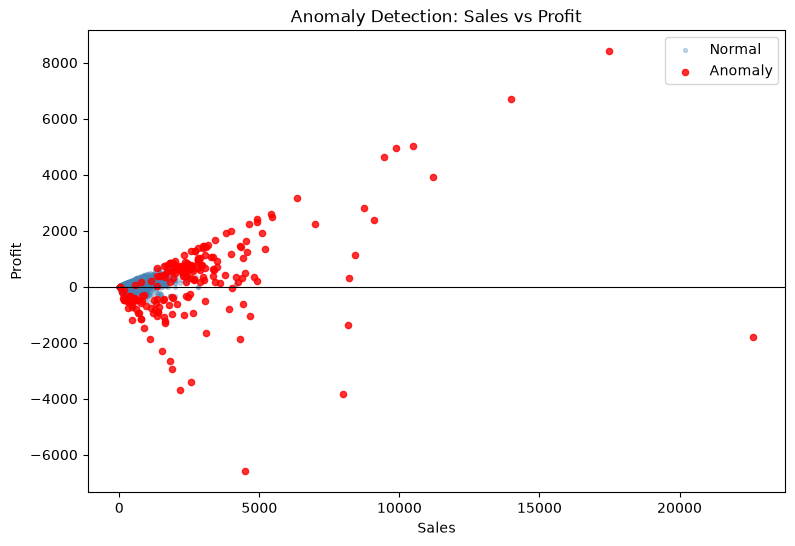

In [45]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 6))
plt.scatter(
    df_clean.loc[~df_clean["Is_Anomaly"], "Sales"],
    df_clean.loc[~df_clean["Is_Anomaly"], "Profit"],
    s=8, alpha=0.3, label="Normal", color="steelblue"
)
plt.scatter(
    df_clean.loc[df_clean["Is_Anomaly"], "Sales"],
    df_clean.loc[df_clean["Is_Anomaly"], "Profit"],
    s=20, alpha=0.8, label="Anomaly", color="red"
)
plt.axhline(0, color="black", linewidth=0.8)
plt.xlabel("Sales")
plt.ylabel("Profit")
plt.title("Anomaly Detection: Sales vs Profit")
plt.legend()
plt.show()

In [ ]:
import pickle

with open("isolation_forest_model.pkl", "wb") as f:
    pickle.dump(iso_forest, f)

df_clean.to_csv("Superstore_with_anomalies.csv", index=False)

anomalies.to_csv("flagged_anomalies.csv", index=False)


In [47]:
high_sales_negative_profit.to_csv("high_sales_loss_anomalies.csv", index=False)

In [29]:
# Basic business KPIs

total_sales = df_clean["Sales"].sum()
total_profit = df_clean["Profit"].sum()
total_quantity = df_clean["Quantity"].sum()
total_orders = df_clean["Order ID"].nunique()
total_customers = df_clean["Customer ID"].nunique()

overall_profit_margin = (total_profit / total_sales) * 100

print("Total Sales:", round(total_sales, 2))
print("Total Profit:", round(total_profit, 2))
print("Total Quantity Sold:", total_quantity)
print("Total Orders:", total_orders)
print("Total Customers:", total_customers)
print("Overall Profit Margin:", round(overall_profit_margin, 2), "%")

Total Sales: 2297200.86
Total Profit: 286397.02
Total Quantity Sold: 37873
Total Orders: 5009
Total Customers: 793
Overall Profit Margin: 12.47 %


In [30]:
category_sales = (
    df_clean.groupby("Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

print(category_sales)

Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64


In [31]:
category_profit = (
    df_clean.groupby("Category")["Profit"]
    .sum()
    .sort_values(ascending=False)
)

print(category_profit)

Category
Technology         145454.9481
Office Supplies    122490.8008
Furniture           18451.2728
Name: Profit, dtype: float64


In [32]:
region_sales = (
    df_clean.groupby("Region")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

print(region_sales)

Region
West       725457.8245
East       678781.2400
Central    501239.8908
South      391721.9050
Name: Sales, dtype: float64


In [33]:
region_profit = (
    df_clean.groupby("Region")["Profit"]
    .sum()
    .sort_values(ascending=False)
)

print(region_profit)

Region
West       108418.4489
East        91522.7800
South       46749.4303
Central     39706.3625
Name: Profit, dtype: float64


In [34]:
monthly_sales = (
    df_clean.groupby(["Year", "Month"])["Sales"]
    .sum()
    .reset_index()
)

print(monthly_sales)

    Year  Month        Sales
0   2014      1   14236.8950
1   2014      2    4519.8920
2   2014      3   55691.0090
3   2014      4   28295.3450
4   2014      5   23648.2870
5   2014      6   34595.1276
6   2014      7   33946.3930
7   2014      8   27909.4685
8   2014      9   81777.3508
9   2014     10   31453.3930
10  2014     11   78628.7167
11  2014     12   69545.6205
12  2015      1   18174.0756
13  2015      2   11951.4110
14  2015      3   38726.2520
15  2015      4   34195.2085
16  2015      5   30131.6865
17  2015      6   24797.2920
18  2015      7   28765.3250
19  2015      8   36898.3322
20  2015      9   64595.9180
21  2015     10   31404.9235
22  2015     11   75972.5635
23  2015     12   74919.5212
24  2016      1   18542.4910
25  2016      2   22978.8150
26  2016      3   51715.8750
27  2016      4   38750.0390
28  2016      5   56987.7280
29  2016      6   40344.5340
30  2016      7   39261.9630
31  2016      8   31115.3743
32  2016      9   73410.0249
33  2016     1

In [35]:
monthly_profit = (
    df_clean.groupby(["Year", "Month"])["Profit"]
    .sum()
    .reset_index()
)

print(monthly_profit)


    Year  Month      Profit
0   2014      1   2450.1907
1   2014      2    862.3084
2   2014      3    498.7299
3   2014      4   3488.8352
4   2014      5   2738.7096
5   2014      6   4976.5244
6   2014      7   -841.4826
7   2014      8   5318.1050
8   2014      9   8328.0994
9   2014     10   3448.2573
10  2014     11   9292.1269
11  2014     12   8983.5699
12  2015      1  -3281.0070
13  2015      2   2813.8508
14  2015      3   9732.0978
15  2015      4   4187.4962
16  2015      5   4667.8690
17  2015      6   3335.5572
18  2015      7   3288.6483
19  2015      8   5355.8084
20  2015      9   8209.1627
21  2015     10   2817.3660
22  2015     11  12474.7884
23  2015     12   8016.9659
24  2016      1   2824.8233
25  2016      2   5004.5795
26  2016      3   3611.9680
27  2016      4   2977.8149
28  2016      5   8662.1464
29  2016      6   4750.3781
30  2016      7   4432.8779
31  2016      8   2062.0693
32  2016      9   9328.6576
33  2016     10  16243.1425
34  2016     11   40

In [36]:
top_products = (
    df_clean.groupby("Product Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_products)

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64


In [37]:
top_profit_products = (
    df_clean.groupby("Product Name")["Profit"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_profit_products)

Product Name
Canon imageCLASS 2200 Advanced Copier                                          25199.9280
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind     7753.0390
Hewlett Packard LaserJet 3310 Copier                                            6983.8836
Canon PC1060 Personal Laser Copier                                              4570.9347
HP Designjet T520 Inkjet Large Format Printer - 24" Color                       4094.9766
Ativa V4110MDD Micro-Cut Shredder                                               3772.9461
3D Systems Cube Printer, 2nd Generation, Magenta                                3717.9714
Plantronics Savi W720 Multi-Device Wireless Headset System                      3696.2820
Ibico EPK-21 Electric Binding System                                            3345.2823
Zebra ZM400 Thermal Label Printer                                               3343.5360
Name: Profit, dtype: float64


In [38]:
def get_kpis(data):
    total_sales = data["Sales"].sum()
    total_profit = data["Profit"].sum()
    total_quantity = data["Quantity"].sum()
    total_orders = data["Order ID"].nunique()
    total_customers = data["Customer ID"].nunique()
    profit_margin = (total_profit / total_sales) * 100

    return {
        "total_sales": round(total_sales, 2),
        "total_profit": round(total_profit, 2),
        "total_quantity": int(total_quantity),
        "total_orders": int(total_orders),
        "total_customers": int(total_customers),
        "profit_margin": round(profit_margin, 2)
    }

In [39]:
def get_category_performance(data):
    result = (
        data.groupby("Category")
        .agg(
            Sales=("Sales", "sum"),
            Profit=("Profit", "sum"),
            Quantity=("Quantity", "sum")
        )
        .reset_index()
        .sort_values("Sales", ascending=False)
    )

    return result

In [40]:
def get_region_performance(data):
    result = (
        data.groupby("Region")
        .agg(
            Sales=("Sales", "sum"),
            Profit=("Profit", "sum"),
            Quantity=("Quantity", "sum")
        )
        .reset_index()
        .sort_values("Sales", ascending=False)
    )

    return result

In [41]:
def get_monthly_sales(data):
    result = (
        data.groupby(["Year", "Month"])
        .agg(
            Sales=("Sales", "sum"),
            Profit=("Profit", "sum")
        )
        .reset_index()
    )

    return result


In [42]:
def get_top_products(data, n=10):
    result = (
        data.groupby("Product Name")
        .agg(
            Sales=("Sales", "sum"),
            Profit=("Profit", "sum"),
            Quantity=("Quantity", "sum")
        )
        .reset_index()
        .sort_values("Sales", ascending=False)
        .head(n)
    )

    return result

In [43]:
print(get_kpis(df_clean))

{'total_sales': np.float64(2297200.86), 'total_profit': np.float64(286397.02), 'total_quantity': 37873, 'total_orders': 5009, 'total_customers': 793, 'profit_margin': np.float64(12.47)}


In [44]:
display(get_category_performance(df_clean))

,Category,Sales,Profit,Quantity
2,Technology,836154.0330,145454.9481,6939
0,Furniture,741999.7953,18451.2728,8028
1,Office Supplies,719047.0320,122490.8008,22906


In [45]:
display(get_region_performance(df_clean))

,Region,Sales,Profit,Quantity
3,West,725457.8245,108418.4489,12266
1,East,678781.2400,91522.7800,10618
0,Central,501239.8908,39706.3625,8780
2,South,391721.9050,46749.4303,6209


In [46]:
display(get_monthly_sales(df_clean))

,Year,Month,Sales,Profit
0,2014,1,14236.8950,2450.1907
1,2014,2,4519.8920,862.3084
2,2014,3,55691.0090,498.7299
3,2014,4,28295.3450,3488.8352
4,2014,5,23648.2870,2738.7096
5,2014,6,34595.1276,4976.5244
6,2014,7,33946.3930,-841.4826
7,2014,8,27909.4685,5318.1050
8,2014,9,81777.3508,8328.0994
9,2014,10,31453.3930,3448.2573


In [47]:
display(get_top_products(df_clean))

,Product Name,Sales,Profit,Quantity
404,Canon imageCLASS 2200 Advanced Copier,61599.824,2.519993e+04,20
650,Fellowes PB500 Electric Punch Plastic Comb Bin...,27453.384,7.753039e+03,31
444,Cisco TelePresence System EX90 Videoconferenci...,22638.480,-1.811078e+03,6
786,HON 5400 Series Task Chairs for Big and Tall,21870.576,5.684342e-14,39
686,GBC DocuBind TL300 Electric Binding System,19823.479,2.233505e+03,37
688,GBC Ibimaster 500 Manual ProClick Binding System,19024.500,7.609800e+02,48
805,Hewlett Packard LaserJet 3310 Copier,18839.686,6.983884e+03,38
787,HP Designjet T520 Inkjet Large Format Printer ...,18374.895,4.094977e+03,12
683,GBC DocuBind P400 Electric Binding System,17965.068,-1.878166e+03,27
813,High Speed Automatic Electric Letter Opener,17030.312,-2.620048e+02,11


In [48]:
# Yearly Sales and Profit

yearly_performance = (
    df_clean.groupby("Year")
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum")
    )
    .reset_index()
)

# Calculate year-over-year growth
yearly_performance["Sales Growth %"] = (
    yearly_performance["Sales"].pct_change() * 100
)

yearly_performance["Profit Growth %"] = (
    yearly_performance["Profit"].pct_change() * 100
)

display(yearly_performance.round(2))

,Year,Sales,Profit,Sales Growth %,Profit Growth %
0,2014,484247.50,49543.97,NaN,NaN
1,2015,470532.51,61618.60,-2.83,24.37
2,2016,609205.60,81795.17,29.47,32.74
3,2017,733215.26,93439.27,20.36,14.24


In [49]:
category_profitability = (
    df_clean.groupby("Category")
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum")
    )
    .reset_index()
)

category_profitability["Profit Margin %"] = (
    category_profitability["Profit"] /
    category_profitability["Sales"] * 100
)

display(category_profitability.round(2))

,Category,Sales,Profit,Profit Margin %
0,Furniture,741999.80,18451.27,2.49
1,Office Supplies,719047.03,122490.80,17.04
2,Technology,836154.03,145454.95,17.40


In [50]:
loss_products = (
    df_clean.groupby("Product Name")
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        Quantity=("Quantity", "sum")
    )
    .reset_index()
)

loss_products = (
    loss_products[loss_products["Profit"] < 0]
    .sort_values("Profit")
)

display(loss_products.head(20))

,Product Name,Sales,Profit,Quantity
475,Cubify CubeX 3D Printer Double Head Print,11099.9630,-8879.9704,9
985,Lexmark MX611dhe Monochrome Laser Printer,16829.9010,-4589.9730,18
476,Cubify CubeX 3D Printer Triple Head Print,7999.9800,-3839.9904,4
425,Chromcraft Bull-Nose Wood Oval Conference Tabl...,9917.6400,-2876.1156,27
376,Bush Advantage Collection Racetrack Conference...,9544.7250,-1934.3976,33
683,GBC DocuBind P400 Electric Binding System,17965.0680,-1878.1662,27
444,Cisco TelePresence System EX90 Videoconferenci...,22638.4800,-1811.0784,6
1043,Martin Yale Chadless Opener Electric Letter Op...,16656.2000,-1299.1836,22
285,Balt Solid Wood Round Tables,6518.7540,-1201.0581,19
364,BoxOffice By Design Rectangular and Half-Moon ...,1706.2500,-1148.4375,15


In [51]:
high_sales_loss = loss_products.sort_values(
    "Sales",
    ascending=False
)

display(high_sales_loss.head(20))

,Product Name,Sales,Profit,Quantity
444,Cisco TelePresence System EX90 Videoconferenci...,22638.4800,-1811.0784,6
683,GBC DocuBind P400 Electric Binding System,17965.0680,-1878.1662,27
813,High Speed Automatic Electric Letter Opener,17030.3120,-262.0048,11
985,Lexmark MX611dhe Monochrome Laser Printer,16829.9010,-4589.9730,18
1043,Martin Yale Chadless Opener Electric Letter Op...,16656.2000,-1299.1836,22
1351,"Riverside Palais Royal Lawyers Bookcase, Royal...",15610.9656,-669.5448,24
368,Bretford Rectangular Conference Table Tops,12995.2915,-327.2331,46
475,Cubify CubeX 3D Printer Double Head Print,11099.9630,-8879.9704,9
425,Chromcraft Bull-Nose Wood Oval Conference Tabl...,9917.6400,-2876.1156,27
376,Bush Advantage Collection Racetrack Conference...,9544.7250,-1934.3976,33


In [52]:
discount_analysis = (
    df_clean.groupby("Discount")
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        Quantity=("Quantity", "sum")
    )
    .reset_index()
)

discount_analysis["Profit Margin %"] = (
    discount_analysis["Profit"] /
    discount_analysis["Sales"] * 100
)

display(discount_analysis.round(2))

,Discount,Sales,Profit,Quantity,Profit Margin %
0,0.00,1087908.47,320987.60,18267,29.51
1,0.10,54369.35,9029.18,373,16.61
2,0.15,27558.52,1418.99,198,5.15
3,0.20,764594.37,90337.31,13660,11.82
4,0.30,103226.66,-10369.28,849,-10.05
5,0.32,14493.46,-2391.14,105,-16.50
6,0.40,116417.78,-23057.05,786,-19.81
7,0.45,5484.97,-2493.11,45,-45.45
8,0.50,58918.54,-20506.43,241,-34.80
9,0.60,6644.70,-5944.66,501,-89.46


In [53]:
segment_analysis = (
    df_clean.groupby("Segment")
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        Quantity=("Quantity", "sum"),
        Customers=("Customer ID", "nunique"),
        Orders=("Order ID", "nunique")
    )
    .reset_index()
)

segment_analysis["Profit Margin %"] = (
    segment_analysis["Profit"] /
    segment_analysis["Sales"] * 100
)

display(segment_analysis.round(2))

,Segment,Sales,Profit,Quantity,Customers,Orders,Profit Margin %
0,Consumer,1161401.34,134119.21,19521,409,2586,11.55
1,Corporate,706146.37,91979.13,11608,236,1514,13.03
2,Home Office,429653.15,60298.68,6744,148,909,14.03


In [54]:
region_category = (
    df_clean.groupby(["Region", "Category"])
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        Quantity=("Quantity", "sum")
    )
    .reset_index()
)

region_category["Profit Margin %"] = (
    region_category["Profit"] /
    region_category["Sales"] * 100
)

display(region_category.round(2))

,Region,Category,Sales,Profit,Quantity,Profit Margin %
0,Central,Furniture,163797.16,-2871.05,1827,-1.75
1,Central,Office Supplies,167026.42,8879.98,5409,5.32
2,Central,Technology,170416.31,33697.43,1544,19.77
3,East,Furniture,208291.20,3046.17,2214,1.46
4,East,Office Supplies,205516.06,41014.58,6462,19.96
5,East,Technology,264973.98,47462.04,1942,17.91
6,South,Furniture,117298.68,6771.21,1291,5.77
7,South,Office Supplies,125651.31,19986.39,3800,15.91
8,South,Technology,148771.91,19991.83,1118,13.44
9,West,Furniture,252612.74,11504.95,2696,4.55


In [55]:
worst_region_category = region_category.sort_values(
    "Profit"
)

display(worst_region_category.head(10).round(2))

,Region,Category,Sales,Profit,Quantity,Profit Margin %
0,Central,Furniture,163797.16,-2871.05,1827,-1.75
3,East,Furniture,208291.20,3046.17,2214,1.46
6,South,Furniture,117298.68,6771.21,1291,5.77
1,Central,Office Supplies,167026.42,8879.98,5409,5.32
9,West,Furniture,252612.74,11504.95,2696,4.55
7,South,Office Supplies,125651.31,19986.39,3800,15.91
8,South,Technology,148771.91,19991.83,1118,13.44
2,Central,Technology,170416.31,33697.43,1544,19.77
4,East,Office Supplies,205516.06,41014.58,6462,19.96
11,West,Technology,251991.83,44303.65,2335,17.58


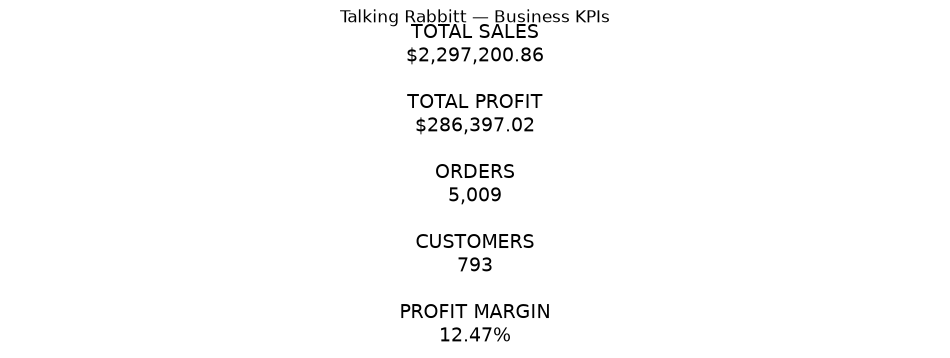

In [56]:
import matplotlib.pyplot as plt

kpis = get_kpis(df_clean)

fig, ax = plt.subplots(figsize=(12, 4))

ax.axis("off")

kpi_text = (
    f"TOTAL SALES\n${kpis['total_sales']:,.2f}\n\n"
    f"TOTAL PROFIT\n${kpis['total_profit']:,.2f}\n\n"
    f"ORDERS\n{kpis['total_orders']:,}\n\n"
    f"CUSTOMERS\n{kpis['total_customers']:,}\n\n"
    f"PROFIT MARGIN\n{kpis['profit_margin']:.2f}%"
)

ax.text(
    0.5,
    0.5,
    kpi_text,
    ha="center",
    va="center",
    fontsize=14
)

plt.title("Talking Rabbitt — Business KPIs")
plt.show()

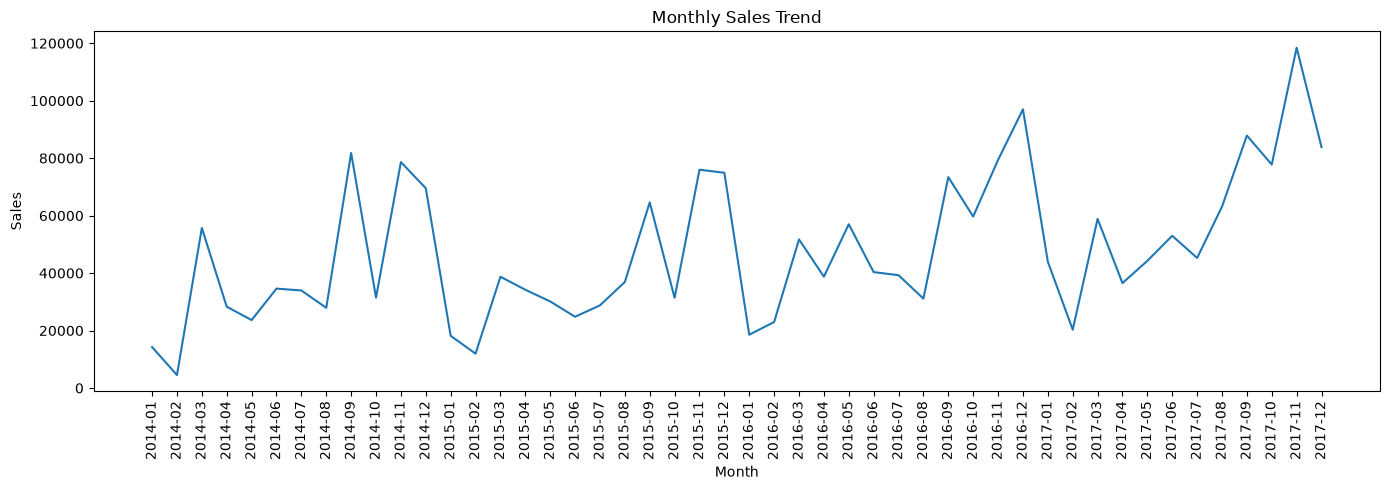

In [57]:
monthly = (
    df_clean.groupby("Order Date")["Sales"]
    .sum()
    .reset_index()
)

monthly["Year-Month"] = monthly["Order Date"].dt.to_period("M")

monthly_sales = (
    monthly.groupby("Year-Month")["Sales"]
    .sum()
)

plt.figure(figsize=(14, 5))

plt.plot(
    monthly_sales.index.astype(str),
    monthly_sales.values
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

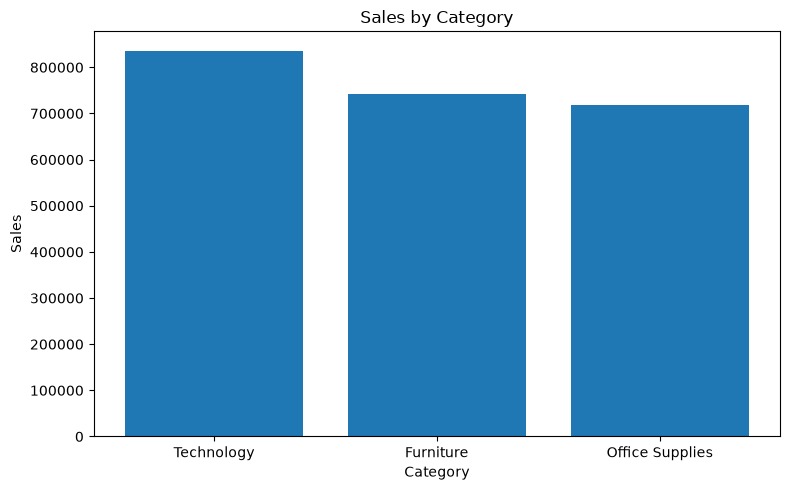

In [58]:
category = (
    df_clean.groupby("Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))

plt.bar(
    category.index,
    category.values
)

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")

plt.tight_layout()
plt.show()

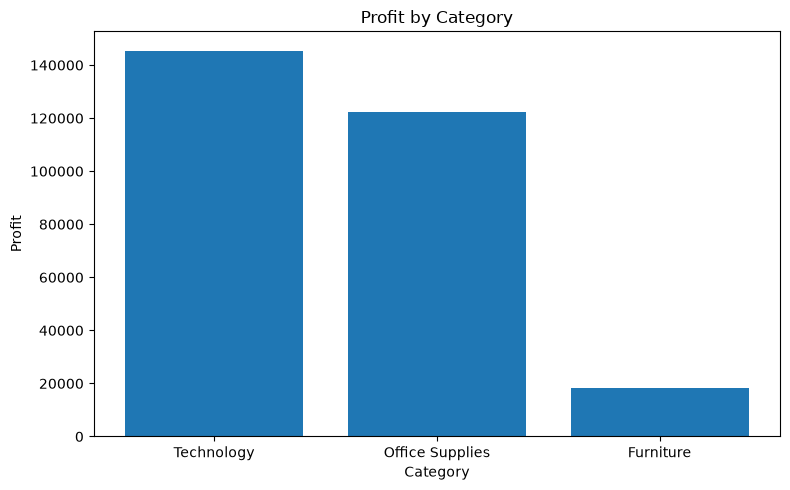

In [59]:
category_profit = (
    df_clean.groupby("Category")["Profit"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))

plt.bar(
    category_profit.index,
    category_profit.values
)

plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit")

plt.tight_layout()
plt.show()

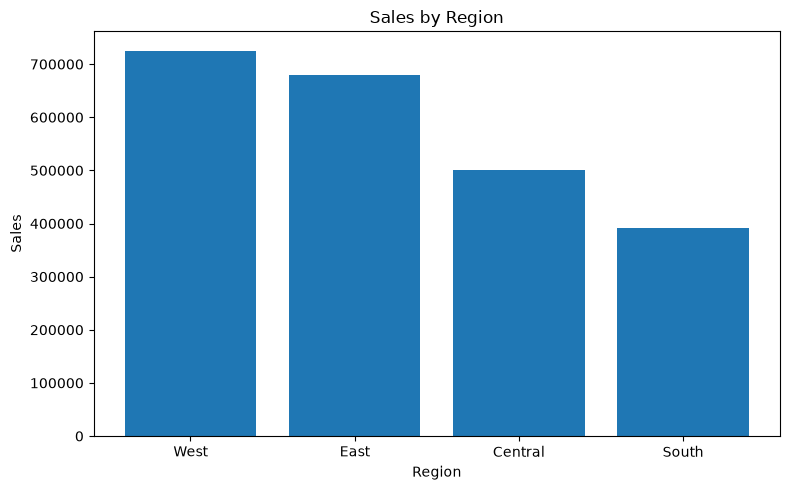

In [60]:
region = (
    df_clean.groupby("Region")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))

plt.bar(
    region.index,
    region.values
)

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")

plt.tight_layout()
plt.show()

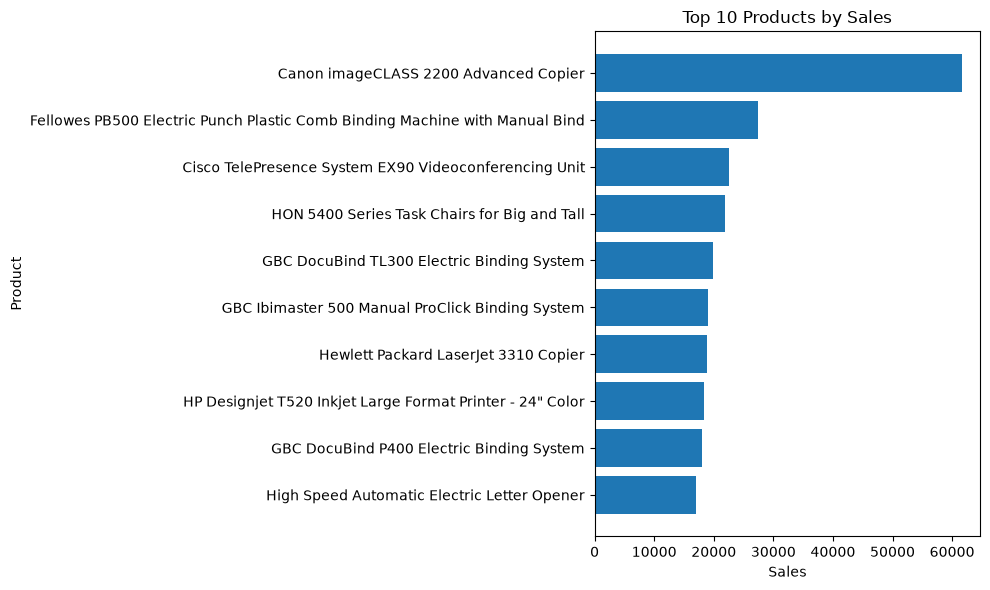

In [61]:
top_products = (
    df_clean.groupby("Product Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_products.index[::-1],
    top_products.values[::-1]
)

plt.title("Top 10 Products by Sales")
plt.xlabel("Sales")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

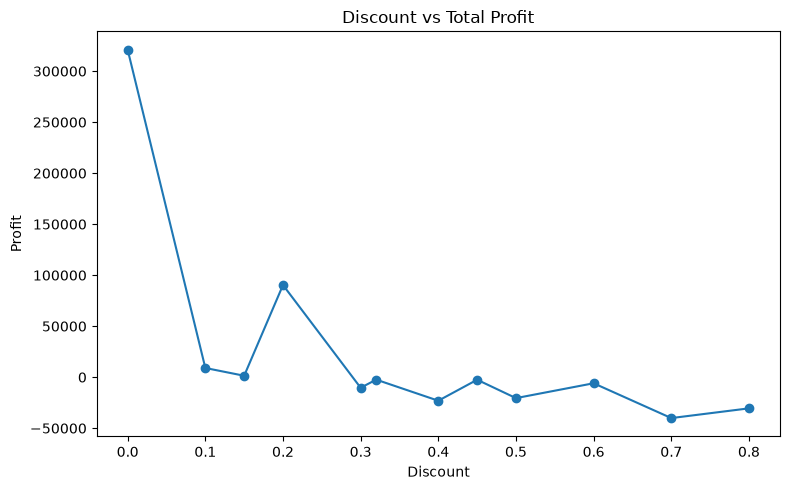

In [62]:
discount_profit = (
    df_clean.groupby("Discount")["Profit"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(8, 5))

plt.plot(
    discount_profit["Discount"],
    discount_profit["Profit"],
    marker="o"
)

plt.title("Discount vs Total Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")

plt.tight_layout()
plt.show()

In [63]:
import os

print(os.listdir("/content"))

FileNotFoundError: [WinError 3] The system cannot find the path specified: '/content'

In [ ]:
df_clean.to_csv(
    "/content/Superstore_cleaned.csv",
    index=False
)

In [ ]:
from google.colab import files

files.download("/content/Superstore_cleaned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>